# 01 · Bronze → Silver : vérification et nettoyage des questions

**Entrée :** `bronze/questions_raw.csv` (données brutes OpenTDB, non modifiées)
**Sorties :**
- `silver/questions.parquet` : 1 ligne = 1 question, textes propres, identifiant stable
- `silver/question_options.parquet` : 1 ligne = 1 option de réponse (dépliage des réponses)

Plan :
1. Chargement
2. Vérification du contrat Bronze (consigne du prof)
3. Diagnostic qualité
4. Nettoyage
5. Contrôles après nettoyage
6. Dépliage des réponses
7. Écriture en Silver

In [1]:
import hashlib
import html
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Le notebook peut être lancé depuis la racine du projet ou depuis notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BRONZE_FILE = ROOT / "bronze" / "questions_raw.csv"
SILVER_DIR = ROOT / "silver"

pd.set_option("display.max_colwidth", 120)
print("Racine du projet :", ROOT)
print("Fichier bronze trouvé :", BRONZE_FILE.exists())

Racine du projet : /Users/carladelmotte/TP TRIVIAL/tp_trivial
Fichier bronze trouvé : True


## 1. Chargement

In [2]:
raw = pd.read_csv(BRONZE_FILE)
print(raw.shape)
raw.head()

(5299, 6)


,type,difficulty,category,question,correct_answer,incorrect_answers
0,multiple,easy,Geography,What country is the second largest in the world by area?,Canada,"[""Russia"", ""China"", ""United States of America""]"
1,multiple,hard,General Knowledge,"According to Fair Works Australia, how long do you have to work to get Long Service Leave?",7 years,"[""2 years"", ""8 years"", ""6 months""]"
2,multiple,easy,Science: Computers,"According to the International System of Units, how many bytes are in a kilobyte of RAM?",1000,"[""512"", ""1024"", ""500""]"
3,multiple,hard,Entertainment: Music,"In Kendrick Lamar&#039;s 2012 album, &quot;Good Kid, M.A.A.D City&quot;, the album&#039;s story takes place in which...",Compton,"[""Detroit"", ""New York"", ""Baltimore""]"
4,boolean,easy,Entertainment: Video Games,Ryuji Sakamoto is a character from Final Fantasy.,False,"[""True""]"


## 2. Vérification du contrat Bronze

Consigne : ~5 299 questions, 6 colonnes (`type, difficulty, category, question, correct_answer, incorrect_answers`), 1 ligne = 1 question.
Chaque contrôle affiche OK ou KO.

In [3]:
EXPECTED_COLUMNS = ["type", "difficulty", "category", "question", "correct_answer", "incorrect_answers"]
incorrect_lists = raw["incorrect_answers"].apply(json.loads)

checks = {
    "Nombre de lignes = 5299": len(raw) == 5299,
    "Colonnes attendues": list(raw.columns) == EXPECTED_COLUMNS,
    "Aucune valeur manquante": raw.isna().sum().sum() == 0,
    "type ∈ {multiple, boolean}": raw["type"].isin(["multiple", "boolean"]).all(),
    "difficulty ∈ {easy, medium, hard}": raw["difficulty"].isin(["easy", "medium", "hard"]).all(),
    "incorrect_answers est une liste JSON valide": incorrect_lists.apply(lambda x: isinstance(x, list)).all(),
    "QCM : 3 mauvaises réponses": (incorrect_lists[raw["type"] == "multiple"].str.len() == 3).all(),
    "Vrai/Faux : 1 mauvaise réponse": (incorrect_lists[raw["type"] == "boolean"].str.len() == 1).all(),
    "Vrai/Faux : réponse True ou False": raw.loc[raw["type"] == "boolean", "correct_answer"].isin(["True", "False"]).all(),
}

for name, ok in checks.items():
    print(("OK  " if ok else "KO  ") + name)

OK  Nombre de lignes = 5299
OK  Colonnes attendues
OK  Aucune valeur manquante
OK  type ∈ {multiple, boolean}
OK  difficulty ∈ {easy, medium, hard}
OK  incorrect_answers est une liste JSON valide
OK  QCM : 3 mauvaises réponses
OK  Vrai/Faux : 1 mauvaise réponse
OK  Vrai/Faux : réponse True ou False


## 3. Diagnostic qualité

### Répartition des questions

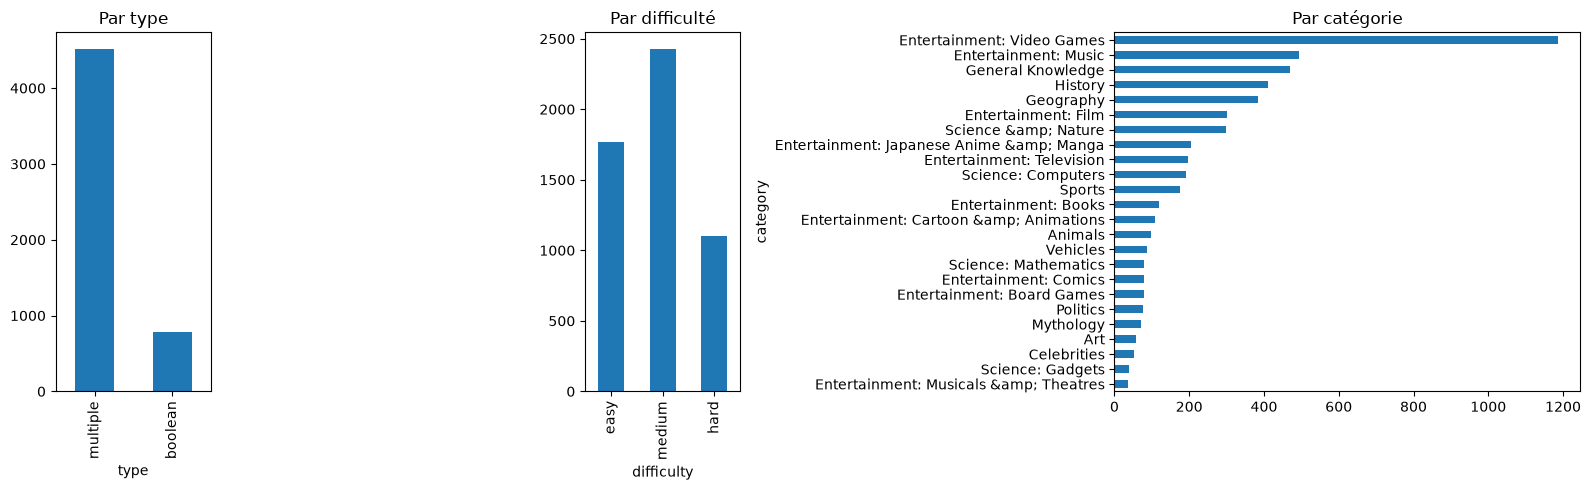

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 1, 3]})
raw["type"].value_counts().plot.bar(ax=axes[0], title="Par type")
raw["difficulty"].value_counts().reindex(["easy", "medium", "hard"]).plot.bar(ax=axes[1], title="Par difficulté")
raw["category"].value_counts().sort_values().plot.barh(ax=axes[2], title="Par catégorie")
plt.tight_layout()
plt.show()

### Encodage HTML

OpenTDB renvoie les textes encodés en HTML (`&quot;`, `&#039;`, `&amp;`...). Il faut les décoder, sinon le modèle d'IA lira des questions illisibles et la comparaison des réponses sera faussée.

In [5]:
HTML_ENTITY = r"&[a-zA-Z#0-9]+;"
text_cols = ["category", "question", "correct_answer", "incorrect_answers"]

pd.DataFrame({
    "lignes avec entités HTML": [raw[c].str.contains(HTML_ENTITY).sum() for c in text_cols],
    "lignes avec espaces en trop": [(raw[c] != raw[c].str.strip()).sum() for c in text_cols],
}, index=text_cols)

,lignes avec entités HTML,lignes avec espaces en trop
category,647,0
question,2112,109
correct_answer,164,56
incorrect_answers,298,0


In [6]:
# Les entités les plus fréquentes
raw["question"].str.findall(HTML_ENTITY).explode().value_counts().head(10)

question
&quot;      3256
&#039;      1111
&eacute;      50
&amp;         25
&rsquo;       19
&ldquo;       16
&rdquo;       16
&shy;         16
&deg;          8
&ouml;         6
Name: count, dtype: int64

In [7]:
# Exemple avant nettoyage
raw.loc[raw["question"].str.contains(HTML_ENTITY), ["question", "correct_answer"]].head(5)

,question,correct_answer
3,"In Kendrick Lamar&#039;s 2012 album, &quot;Good Kid, M.A.A.D City&quot;, the album&#039;s story takes place in which...",Compton
5,During what war did the &quot;Cuban Missile Crisis&quot; occur?,Cold War
6,Who made Garry&#039;s Mod?,Garry Newman
7,"In 2006, which band released their debut album &quot;A Fever You Can&#039;t Sweat Out&quot;?",Panic! At the Disco
8,"In the anime series &quot;Full Metal Alchemist&quot;, what do Alchemists consider the greatest taboo?",Human Transmutation


### Doublons

On cherche les questions dont le texte apparaît plusieurs fois.

In [8]:
print("Lignes strictement identiques :", raw.duplicated().sum())
dup = raw[raw.duplicated("question", keep=False)].sort_values("question")
print("Questions dont le texte apparaît plusieurs fois :", dup["question"].nunique())
dup[["category", "difficulty", "question", "correct_answer", "incorrect_answers"]]

Lignes strictement identiques : 0
Questions dont le texte apparaît plusieurs fois : 4


,category,difficulty,question,correct_answer,incorrect_answers
807,Science: Mathematics,easy,How many sides does a heptagon have?,7,"[""8"", ""6"", ""5""]"
4859,Science: Mathematics,easy,How many sides does a heptagon have?,7,"[""5"", ""4"", ""9""]"
1291,General Knowledge,easy,The &ldquo;fairy&rdquo; type made it&rsquo;s debut in which generation of the Pokemon core series games?,6th,"[""2nd"", ""7th"", ""4th""]"
4471,Entertainment: Video Games,easy,The &ldquo;fairy&rdquo; type made it&rsquo;s debut in which generation of the Pokemon core series games?,6th,"[""2nd"", ""7th"", ""4th""]"
280,History,hard,When did the French Revolution begin?,1789,"[""1823"", ""1756"", ""1799""]"
4151,History,hard,When did the French Revolution begin?,May 05 1789,"[""April 12 1789"", ""April 05 1789"", ""May 06 1799""]"
1343,Art,easy,Who painted the Mona Lisa?,Leonardo da Vinci,"[""Pablo Picasso"", ""Claude Monet"", ""Vincent van Gogh""]"
1810,Art,easy,Who painted the Mona Lisa?,Leonardo da Vinci,"[""Pablo Picasso"", "" Vincent van Gogh"", ""Michelangelo""]"


**Lecture :** aucune ligne n'est strictement identique, mais quelques questions existent en double avec des mauvaises réponses ou une catégorie différentes.
Choix retenu : on supprime les doublons sur le couple (`question`, `correct_answer`) après nettoyage, car poser deux fois la même question au modèle fausserait le benchmark.
Les questions de même texte mais de **bonne réponse différente** (ex. la Révolution française : « 1789 » vs « May 05 1789 ») sont conservées, ce sont deux questions différentes.

## 4. Nettoyage

In [9]:
def clean_text(value: str) -> str:
    """Décode le HTML, retire les césures invisibles et les espaces en trop."""
    value = html.unescape(value)
    value = value.replace("\u00ad", "")   # &shy; (césure invisible)
    value = value.replace("\u00a0", " ")  # espace insécable
    return " ".join(value.split())        # espaces multiples et bords

df = raw.copy()
for col in ["category", "question", "correct_answer"]:
    df[col] = df[col].apply(clean_text)

df["incorrect_answers"] = df["incorrect_answers"].apply(
    lambda s: [clean_text(a) for a in json.loads(s)]
)

df[["question", "correct_answer", "incorrect_answers"]].head()

,question,correct_answer,incorrect_answers
0,What country is the second largest in the world by area?,Canada,"[Russia, China, United States of America]"
1,"According to Fair Works Australia, how long do you have to work to get Long Service Leave?",7 years,"[2 years, 8 years, 6 months]"
2,"According to the International System of Units, how many bytes are in a kilobyte of RAM?",1000,"[512, 1024, 500]"
3,"In Kendrick Lamar's 2012 album, ""Good Kid, M.A.A.D City"", the album's story takes place in which city?",Compton,"[Detroit, New York, Baltimore]"
4,Ryuji Sakamoto is a character from Final Fantasy.,False,[True]


### Enrichissement : famille de catégorie

Les catégories du type `Entertainment: Film` ou `Science: Computers` sont regroupées en grandes familles (`Entertainment`, `Science`), utile pour des analyses moins fines dans le dashboard.

In [10]:
df["category_group"] = df["category"].str.split(":").str[0].str.strip()
df["category_group"] = df["category_group"].replace({"Science & Nature": "Science"})
df.groupby("category_group")["category"].unique().to_frame("catégories")

,catégories
category_group,
Animals,[Animals]
Art,[Art]
Celebrities,[Celebrities]
Entertainment,"[Entertainment: Music, Entertainment: Video Games, Entertainment: Japanese Anime & Manga, Entertainment: Board Games..."
General Knowledge,[General Knowledge]
Geography,[Geography]
History,[History]
Mythology,[Mythology]
Politics,[Politics]


### Suppression des doublons et identifiant stable

In [11]:
before = len(df)
df = df.drop_duplicates(subset=["question", "correct_answer"], keep="first").reset_index(drop=True)
print(f"Doublons supprimés : {before - len(df)}  ->  {len(df)} questions")

Doublons supprimés : 3  ->  5296 questions


In [12]:
# Identifiant stable : un hash de (question, bonne réponse).
# Il reste le même si on relance le scraping, contrairement à un simple numéro de ligne.
def make_id(row) -> str:
    key = f"{row['question']}||{row['correct_answer']}"
    return hashlib.md5(key.encode("utf-8")).hexdigest()[:12]

df["question_id"] = df.apply(make_id, axis=1)
df["nb_options"] = df["incorrect_answers"].str.len() + 1

df = df[["question_id", "type", "difficulty", "category_group", "category",
         "question", "correct_answer", "incorrect_answers", "nb_options"]]
df.head()

,question_id,type,difficulty,category_group,category,question,correct_answer,incorrect_answers,nb_options
0,2dab6beefc42,multiple,easy,Geography,Geography,What country is the second largest in the world by area?,Canada,"[Russia, China, United States of America]",4
1,71ddf486cb21,multiple,hard,General Knowledge,General Knowledge,"According to Fair Works Australia, how long do you have to work to get Long Service Leave?",7 years,"[2 years, 8 years, 6 months]",4
2,3d6d89bb259d,multiple,easy,Science,Science: Computers,"According to the International System of Units, how many bytes are in a kilobyte of RAM?",1000,"[512, 1024, 500]",4
3,2d2d4a5fe02b,multiple,hard,Entertainment,Entertainment: Music,"In Kendrick Lamar's 2012 album, ""Good Kid, M.A.A.D City"", the album's story takes place in which city?",Compton,"[Detroit, New York, Baltimore]",4
4,0db89cec0b8a,boolean,easy,Entertainment,Entertainment: Video Games,Ryuji Sakamoto is a character from Final Fantasy.,False,[True],2


## 5. Contrôles après nettoyage

In [13]:
post_checks = {
    "question_id unique": df["question_id"].is_unique,
    "Plus aucune entité HTML": not any(df[c].str.contains(HTML_ENTITY).any() for c in ["category", "question", "correct_answer"])
                               and not df["incorrect_answers"].explode().str.contains(HTML_ENTITY).any(),
    "Plus d'espaces en trop": all((df[c] == df[c].str.strip()).all() for c in ["question", "correct_answer"]),
    "Aucune question vide": (df["question"].str.len() > 0).all(),
    "Bonne réponse absente des mauvaises réponses": not df.apply(lambda r: r["correct_answer"] in r["incorrect_answers"], axis=1).any(),
}
for name, ok in post_checks.items():
    print(("OK  " if ok else "KO  ") + name)

OK  question_id unique
OK  Plus aucune entité HTML
OK  Plus d'espaces en trop
OK  Aucune question vide
OK  Bonne réponse absente des mauvaises réponses


In [14]:
# Comparaison avant / après sur quelques exemples
idx = raw["question"].str.contains(HTML_ENTITY)
pd.DataFrame({
    "avant": raw.loc[idx, "question"].head(5).values,
    "après": raw.loc[idx, "question"].head(5).apply(clean_text).values,
})

,avant,après
0,"In Kendrick Lamar&#039;s 2012 album, &quot;Good Kid, M.A.A.D City&quot;, the album&#039;s story takes place in which...","In Kendrick Lamar's 2012 album, ""Good Kid, M.A.A.D City"", the album's story takes place in which city?"
1,During what war did the &quot;Cuban Missile Crisis&quot; occur?,"During what war did the ""Cuban Missile Crisis"" occur?"
2,Who made Garry&#039;s Mod?,Who made Garry's Mod?
3,"In 2006, which band released their debut album &quot;A Fever You Can&#039;t Sweat Out&quot;?","In 2006, which band released their debut album ""A Fever You Can't Sweat Out""?"
4,"In the anime series &quot;Full Metal Alchemist&quot;, what do Alchemists consider the greatest taboo?","In the anime series ""Full Metal Alchemist"", what do Alchemists consider the greatest taboo?"


## 6. Dépliage des réponses

Consigne : le dépliage des réponses incorrectes se fait en Silver.
On crée une table longue : **1 ligne = 1 option de réponse**, avec un booléen `is_correct`.
Elle servira à construire les prompts à choix multiples (en mélangeant l'ordre des options) et sera facile à exploiter en SQL avec dbt.

In [15]:
correct = df[["question_id", "correct_answer"]].rename(columns={"correct_answer": "answer"})
correct["is_correct"] = True

incorrect = (df[["question_id", "incorrect_answers"]]
             .explode("incorrect_answers")
             .rename(columns={"incorrect_answers": "answer"}))
incorrect["is_correct"] = False

options = (pd.concat([correct, incorrect], ignore_index=True)
           .sort_values(["question_id", "is_correct"], ascending=[True, False])
           .reset_index(drop=True))
print(options.shape)
options.head(8)

(19606, 3)


,question_id,answer,is_correct
0,001ae04d4bc6,Boeing 747-8,True
1,001ae04d4bc6,Airbus A350-1000,False
2,001ae04d4bc6,Airbus A330-200,False
3,001ae04d4bc6,Boeing 787-10,False
4,0025d638c77a,Spell Valley,True
5,0025d638c77a,Barbarian Bowl,False
6,0025d638c77a,P.E.K.K.A's Playhouse,False
7,0025d638c77a,Royal Arena,False


In [16]:
per_q = options.groupby("question_id").agg(nb=("answer", "size"), nb_correct=("is_correct", "sum"))
options_checks = {
    "Chaque question a exactement 1 bonne réponse": (per_q["nb_correct"] == 1).all(),
    "Nombre d'options cohérent avec nb_options": per_q["nb"].sort_index().equals(df.set_index("question_id")["nb_options"].sort_index()),
    "Toutes les questions sont présentes": set(per_q.index) == set(df["question_id"]),
}
for name, ok in options_checks.items():
    print(("OK  " if ok else "KO  ") + name)

OK  Chaque question a exactement 1 bonne réponse
OK  Nombre d'options cohérent avec nb_options
OK  Toutes les questions sont présentes


## 7. Écriture en Silver

In [17]:
SILVER_DIR.mkdir(exist_ok=True)
df.to_parquet(SILVER_DIR / "questions.parquet", index=False)
options.to_parquet(SILVER_DIR / "question_options.parquet", index=False)

# Relecture pour vérifier
check_q = pd.read_parquet(SILVER_DIR / "questions.parquet")
check_o = pd.read_parquet(SILVER_DIR / "question_options.parquet")
print("questions.parquet        :", check_q.shape)
print("question_options.parquet :", check_o.shape)
check_q.dtypes

questions.parquet        : (5296, 9)
question_options.parquet : (19606, 3)


question_id             str
type                    str
difficulty              str
category_group          str
category                str
question                str
correct_answer          str
incorrect_answers    object
nb_options            int64
dtype: object

## Récapitulatif

| | Bronze | Silver |
|---|---|---|
| Format | CSV | Parquet |
| Encodage HTML | présent | décodé |
| Doublons | quelques questions en double | supprimés sur (question, bonne réponse) |
| Identifiant | aucun | `question_id` stable (hash) |
| Réponses incorrectes | texte JSON | liste + table dépliée `question_options` |
| Enrichissement | | `category_group`, `nb_options` |